# Week 10 — the capstone engagement (Wednesday, 1 hour)

Six exercises on fc-10's `cash` and `capstone` modules and Decision 8. Every rate is **PLANTED TRUTH** on a synthetic
cash-deposit stream. Read `README.md` in this folder first.

In [1]:
import random, sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parents[1]))
from tools.tm_sim_source import load, fc10_module

tm_sim, metrics = load()
cash = fc10_module("runtime.manufacturing.tuning.cash")
decision_log = fc10_module("runtime.manufacturing.tuning.decision_log")
paper = fc10_module("runtime.manufacturing.tuning.paper")

log = decision_log.load()
[d8] = [e for e in log if e["decision_id"] == "D8"]
a, ev = d8["assumptions"], d8["evidence"]
print(d8["decision"], d8["rule_id"], "->", d8["to_threshold"], "· applied:", d8["applied"])

PROPOSE cash_30d -> 15000 · applied: False


## Exercise 1 — the engagement on an unused seed

In [2]:
rows = [{"rule": "naive £10k", "reviews": ev["naive"]["hold_out"]["workload"], "caught": ev["naive"]["hold_out"]["tp"]}]
for fam, j in ev["fitted"].items():
    m = j["meets"]["hold_out"]
    rows.append({"rule": fam, "reviews": j["hold_out"]["workload"], "caught": j["hold_out"]["tp"],
                 "fewer alerts": f"{m['volume_reduction']:.0%}", "recall lost": f"{m['recall_loss']:.0%}",
                 "fits 522": j["fits_capacity"]})
print(pd.DataFrame(rows).to_string(index=False))

           rule  reviews  caught fewer alerts recall lost fits 522
     naive £10k     6207     100          NaN         NaN      NaN
near_line_count      861     100          86%          0%    False
    rolling_sum     4312     100          31%          0%    False


**Read it.** Both fitted rules meet the engagement on the seed nobody had used, and neither fits the capacity.

## Exercise 2 — stress each rule where it is weak

                      near_line_count rolling_sum
drift                            0 pt        0 pt
hold_out                         0 pt        0 pt
stress_fewer_deposits           23 pt        8 pt
stress_longer_spread            10 pt        5 pt
stress_lower_band               11 pt        2 pt


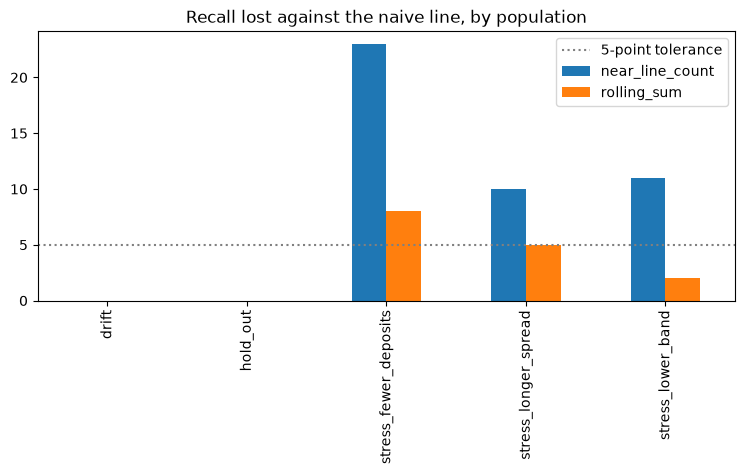

In [3]:
sides = [s for s in next(iter(ev["fitted"].values()))["meets"] if s != "in_sample"]
t = pd.DataFrame({fam: {s: j["meets"][s]["recall_loss"] for s in sides} for fam, j in ev["fitted"].items()})
print((100 * t).round(0).astype(int).astype(str) + " pt")
ax = (100 * t).plot.bar(figsize=(9, 3.5), title="Recall lost against the naive line, by population")
ax.axhline(5, color="grey", ls=":", label="5-point tolerance"); ax.legend();

**Read it.** The signature fails every stress; the line fails only when structurers make fewer deposits. Each
rule's weak dial is different, which is why one stress was not enough.

## Exercise 3 — at capacity, the order is the rule

Work the £15k line's queue to 522 reviews in three orders — signature first, oldest first, and twenty random
orders — on the unused seed.

In [4]:
from collections import defaultdict
pop = cash.generate(seed=a["holdout_seed"])
line, sig, budget = ev["at_capacity"]["line"], ev["at_capacity"]["signature"], a["capacity_budget"]
months = sorted({(t.customer_id, t.value_date[:7]) for t in cash.fired(pop, line)})
hits = defaultdict(int)
for t in cash.fired(pop, sig):
    hits[(t.customer_id, t.value_date[:7])] += 1
planted = {c.customer_id for c in pop.customers if c.planted}
def caught(order): return len({c for c, _m in order[:budget]} & planted)
sig_first = caught(sorted(months, key=lambda m: (-hits[m], m[1], m[0])))
oldest = caught(sorted(months, key=lambda m: (m[1], m[0])))
rand = [caught(random.Random(k).sample(months, len(months))) for k in range(20)]
print(f"{len(months):,} line alerts, {budget} reviews · signature first {sig_first} · oldest first {oldest} · "
      f"random {min(rand)}-{max(rand)}")
print("recorded in D8:", ev["at_capacity"]["sides"]["hold_out"]["ordered_queue"]["tp"],
      "· capacity-fit rule alone:", ev["at_capacity"]["sides"]["hold_out"]["capacity_fit"]["tp"])

4,312 line alerts, 522 reviews · signature first 90 · oldest first 23 · random 21-38
recorded in D8: 90 · capacity-fit rule alone: 88


**Read it.** The same alerts, the same budget: oldest first catches 23, random orders 21–38, signature first 90. At capacity,
choosing the order *is* choosing the rule — which is why D8's finding is capacity, not a line.

## Exercise 4 — D7's candidate on the unused seed

In [5]:
r = ev["d7_revisit"]["rules"]
print(pd.DataFrame({n: {k: r[n][k] for k in ("workload", "customers_alerted", "tp", "attributable_tp")} for n in r}).T)

                      workload  customers_alerted   tp  attributable_tp
champion                  2656                718  120              120
d3_lines                  2323                852  158              158
spike_floor+d3_lines      2678               2043  191              189


## Exercise 5 — eight decisions, one paper

In [6]:
print(pd.DataFrame([{"decision": e["decision_id"], "week": e.get("week"), "call": e["decision"],
                     "evidence": e.get("evidence_kind", "threshold_sweep")} for e in log]).to_string(index=False))
text = paper.render()
print()
print([l for l in text.splitlines() if l.startswith("## ")])

decision  week    call        evidence
      D1     3    HOLD threshold_sweep
      D2     4    HOLD        capacity
      D3     5 SEGMENT        segments
      D4     6    HOLD      challenger
      D5     7    HOLD           drift
      D6     8    HOLD     calibration
      D7     9    HOLD      validation
      D8    10 PROPOSE        capstone

['## 1. Background', '## 2. Method', '## 3. Results', '## 4. Recommendation', '## 5. Limitations']


## For the weekend

Write `weekend_note.md` as the memo you would send the owner: the terms, what each rule does under each stress, why
the order outweighs the line at capacity, and what real data you would need before any apply.